# Exploring trends of Danish & Croissant

In [1]:
from doughflow.data.make_dataset import (
    load_raw_data,
    rename_data
)
from doughflow.data.save_dataset import (
    save_processed_data,
    load_processed_data
)
import seaborn as sns
import matplotlib.pyplot as plt


## Volume Distribution

In [2]:
from doughflow.features.build_features import ProductFeatureExtractor

product_extractor = ProductFeatureExtractor(aggregation_level='item')

In [3]:
# Getting raw data 
df = load_raw_data('../data/raw')

df_cleanCols = rename_data(df)

df_item_level = product_extractor.fit_transform(df_cleanCols)

df_item_level

save_processed_data(df_item_level, "danish_croissant_data.csv", output_dir= '../data/processed')

PosixPath('../data/processed/danish_croissant_data.csv')

### Data Information 

In [4]:
df_item_level.describe()

,quantity
count,1902.00000
mean,41.43428
std,23.57237
min,1.00000
25%,24.00000
50%,37.00000
75%,54.00000
max,145.00000


### Visualizing

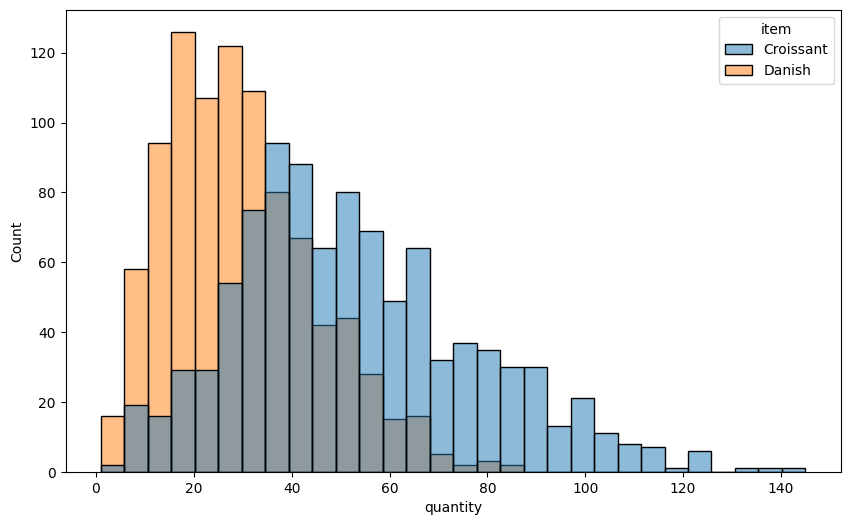

In [5]:
# graphing distribution of items
plt.figure(figsize=(10,6))
sns.histplot(df_item_level, x='quantity', hue= 'item')
plt.show()


## Seasonality Analysis 

### Year-over-year Pattern

In [8]:
# Adding temporal feature to compare between weeks, years , or months
from doughflow.features.build_features import TemporalFeatureExtractor

temporal_extractor = TemporalFeatureExtractor()

df_features = temporal_extractor.fit_transform(df_item_level)

df_features

,date,item,quantity,day_of_week,day_of_month,month,year,week_of_year,is_weekend
0,2021-05-13,Croissant,42,3,13,5,2021,19,False
1,2021-05-13,Danish,27,3,13,5,2021,19,False
2,2021-05-14,Croissant,61,4,14,5,2021,19,False
3,2021-05-14,Danish,27,4,14,5,2021,19,False
4,2021-05-15,Croissant,100,5,15,5,2021,19,True
...,...,...,...,...,...,...,...,...,...
1897,2025-10-25,Danish,42,5,25,10,2025,43,True
1898,2025-10-26,Croissant,37,6,26,10,2025,43,True
1899,2025-10-26,Danish,13,6,26,10,2025,43,True
1900,2025-10-30,Croissant,17,3,30,10,2025,44,False


/var/folders/29/j8y5fr5n52976t5qhqnb312c0000gn/T/ipykernel_62965/329509982.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(df_features, x = 'year', y = 'quantity', hue= 'item', ci= None)


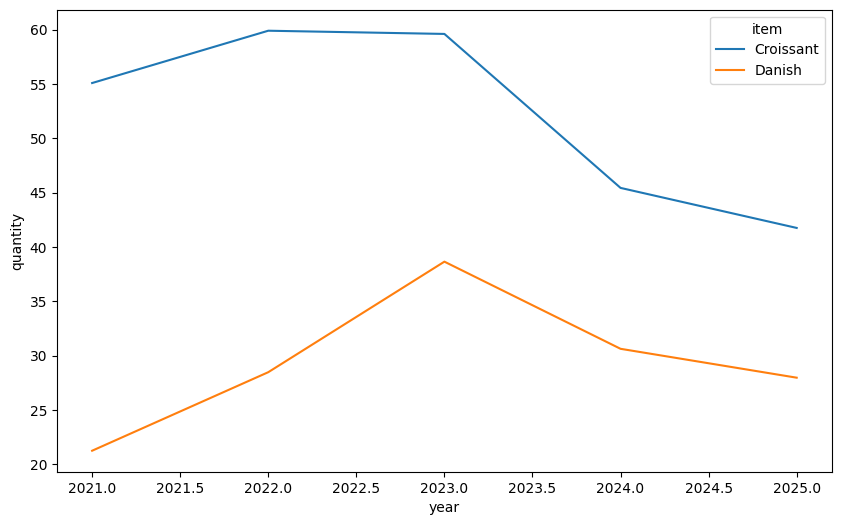

In [13]:
# line plot 

plt.figure(figsize=(10,6))
sns.lineplot(df_features, x = 'year', y = 'quantity', hue= 'item', ci= None)
plt.show()